In [1]:
import os

print(os.listdir("/home/mca/Downloads"))

['Screenshot 2026-07-22 at 14-14-34 Problems - LeetCode.png', 'P6_graph.ipynb', 'pg11_files', 'P7.ipynb', 'wine.csv', '6-9 Data visualization using matplotlib.pdf', 'DSc Lab Cycle Programs 2024 1-40.pdf', 'P9.ipynb', 'pg11.html', 'archive.zip', 'P8.ipynb']


In [10]:
print(df.isnull().sum())

print(df.describe())

print(df['quality'].value_counts())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dio

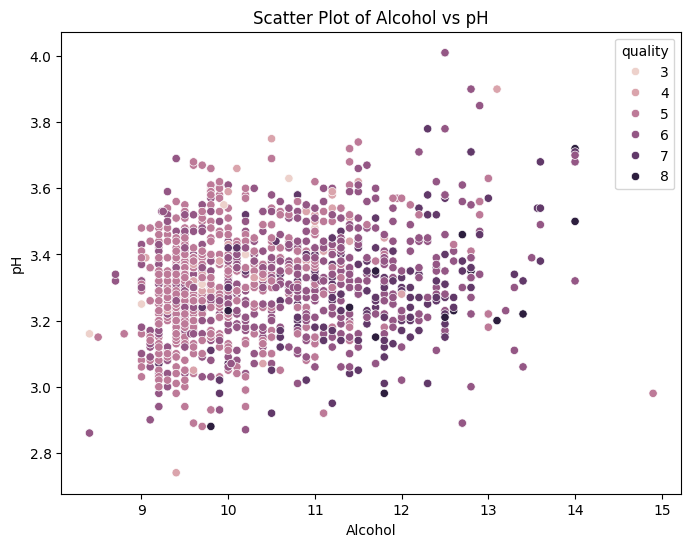

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='alcohol',
    y='pH',
    hue='quality',
    data=df
)

plt.title("Scatter Plot of Alcohol vs pH")
plt.xlabel("Alcohol")
plt.ylabel("pH")
plt.show()

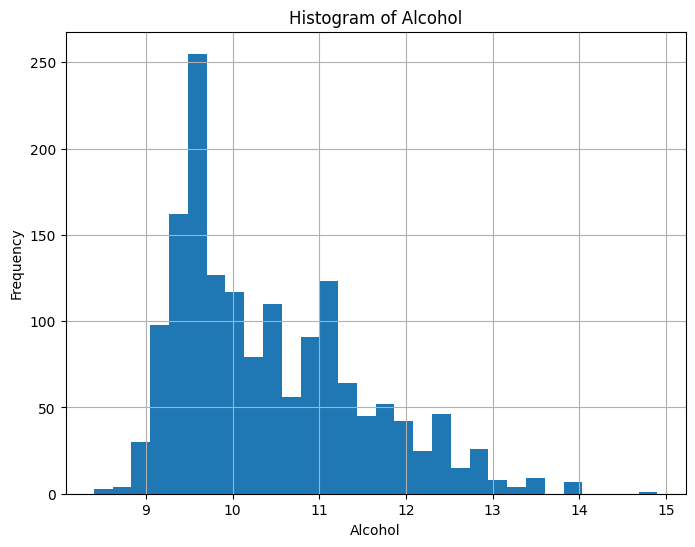

In [12]:
# (ii) Histogram
plt.figure(figsize=(8, 6))

df['alcohol'].hist(bins=30)

plt.title("Histogram of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()

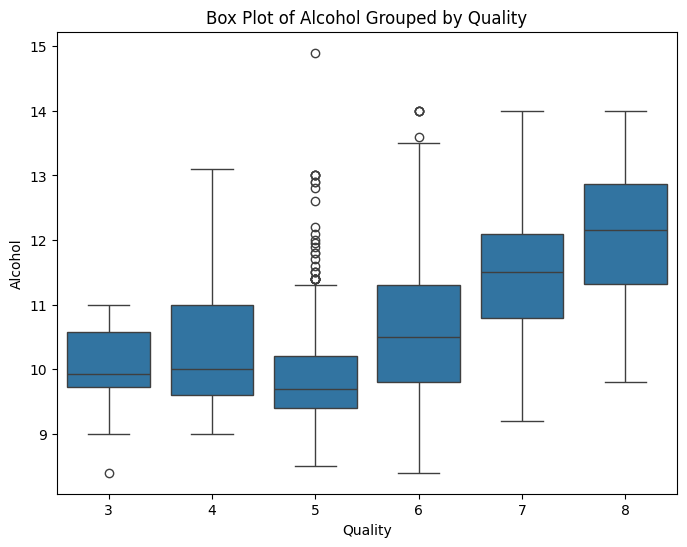

In [13]:
# (iii) Box plot
plt.figure(figsize=(8, 6))

sns.boxplot(x='quality', y='alcohol', data=df)

plt.title("Box Plot of Alcohol Grouped by Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df_cleaned = df.dropna()

X = df_cleaned.drop('quality', axis=1)
y = df_cleaned['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = [1, 3, 5, 7, 9, 11, 13, 15]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy with k={k}: {accuracy:.4f}")

Accuracy with k=1: 0.6219
Accuracy with k=3: 0.5156
Accuracy with k=5: 0.5469
Accuracy with k=7: 0.5500
Accuracy with k=9: 0.5594
Accuracy with k=11: 0.5719
Accuracy with k=13: 0.5687
Accuracy with k=15: 0.5563
